# Firewall Log Clustering with Unsupervised Behavioral Segmentation

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Aprendizado Não Supervisionado<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** September 29, 2025   


---

## 1. Introduction & Objectives

**Problem:**  
Network firewall logs record every connection event passing through a security perimeter. These logs are high-volume and largely unlabeled, making manual analysis impractical. Identifying behavioral patterns without prior labels is a core challenge in network security operations.

**Task Type:**  
Unsupervised Learning, Clustering

**Business or Research Objective:**  
Segment firewall log events into meaningful behavioral groups to support security auditing, anomaly prioritization, and operational monitoring. The goal is to distinguish routine traffic patterns from potentially suspicious or anomalous events without any labeled data.

**Analytical Goal:**  
Apply and compare multiple clustering algorithms (K-Means, Agglomerative Clustering, DBSCAN, Gaussian Mixture Model) on engineered features derived from firewall log records. Reduce dimensionality via PCA before clustering and evaluate results using internal validation metrics.

**Primary Evaluation Metrics:**  
Silhouette Score (cohesion and separation), Davies-Bouldin Index (cluster compactness), Calinski-Harabasz Index (cluster density ratio)

**Success Criteria:**  
Identify a clustering solution with Silhouette Score > 0.6, producing interpretable and well-separated segments that offer actionable security insights.

## 2. Setup & Imports

In [26]:
import warnings
import ipaddress

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

# Global configuration
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Environment ready")
print("Pandas version:", pd.__version__)

Environment ready
Pandas version: 3.0.1


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
Local file `new_logs.csv` (exported firewall log file from a network perimeter device)

**Description:**  
Each row represents a single firewall log event, including metadata about the traffic source, destination, applied rules, and protocol.

**Features:**

| # | Feature | Type | Role | Description |
|---|---------|------|------|-------------|
| 1 | Time | datetime | temporal | Timestamp of the log event |
| 2 | Log comp | categorical | descriptor | Log component (firewall subsystem) |
| 3 | Log subtype | categorical | descriptor | Subtype of the log component |
| 4 | Username | categorical | identity | User associated with the event |
| 5 | Firewall rule | categorical | rule | Numeric firewall rule ID |
| 6 | Firewall rule name | categorical | rule | Human-readable firewall rule name |
| 7 | NAT rule | categorical | rule | NAT rule ID |
| 8 | NAT rule name | categorical | rule | Human-readable NAT rule name |
| 9 | In interface | categorical | network | Ingress network interface |
| 10 | Out interface | categorical | network | Egress network interface |
| 11 | Src IP | string | network | Source IP address |
| 12 | Dst IP | string | network | Destination IP address |
| 13 | Src port | numeric | network | Source TCP/UDP port |
| 14 | Dst port | numeric | network | Destination TCP/UDP port |
| 15 | protocol | categorical | network | Transport protocol (TCP, UDP, etc.) |
| 16 | Rule type | categorical | rule | Type of firewall rule applied |
| 17 | Live PCAP | categorical | diagnostic | Packet capture flag |
| 18 | Message | text | descriptor | Human-readable event description |
| 19 | Log occurrence | numeric | descriptor | Number of times the event was recorded |

**Unit of Analysis:**  
Individual firewall log event

**Target Variable:**  
None (unsupervised task). Cluster labels are inferred.

**Notes:**  
- The dataset is a sample of production firewall logs. IP addresses may include both internal (RFC1918) and external addresses. Timestamps are assumed to reflect the device's local clock.

In [2]:
df = pd.read_csv("dataset/new_logs.csv", low_memory=False)

print("Shape:", df.shape)
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary statistics:")
display(df.describe(include="all"))

Shape: (200, 20)


,Time,Log comp,Log subtype,Username,Firewall rule,Firewall rule name,NAT rule,NAT rule name,In interface,Out interface,Src IP,Dst IP,Src port,Dst port,protocol,Rule type,Live PCAP,Message,Log occurrence,Unnamed: 19
0,2024-07-06 12:29:34,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,45.147.66.142,82.213.48.193,4036,443,TCP,1,Open PCAP,NaN,1,NaN
1,2024-07-06 12:29:30,Firewall Rule,Allowed,NaN,48.0,DMZ-to-WAN,15,Default SNAT IPv4,Port3,Port2,172.17.17.8,10.101.6.4,52907,443,TCP,1,Open PCAP,NaN,1,NaN
2,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,2.0,LAN-2-WAN,15,Default SNAT IPv4,Port1,Port2,192.168.61.137,3.72.193.109,53382,443,TCP,1,Open PCAP,NaN,1,NaN
3,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,5.0,WebNat,10,iqrad webserver - DNAT,Port2,Port3,45.147.66.142,82.213.48.193,32034,443,TCP,1,Open PCAP,NaN,1,NaN
4,2024-07-06 12:29:29,Firewall Rule,Allowed,NaN,48.0,DMZ-to-WAN,14,PublicDNS - SNAT,Port3,Port2,172.17.17.223,23.196.143.19,49302,443,TCP,1,Open PCAP,NaN,1,NaN



Data types:


Time                      str
Log comp                  str
Log subtype               str
Username              float64
Firewall rule         float64
Firewall rule name        str
NAT rule                int64
NAT rule name             str
In interface              str
Out interface             str
Src IP                    str
Dst IP                    str
Src port                int64
Dst port                int64
protocol                  str
Rule type               int64
Live PCAP                 str
Message                   str
Log occurrence          int64
Unnamed: 19           float64
dtype: object


Missing values:


Time                    0
Log comp                0
Log subtype             0
Username              200
Firewall rule           2
Firewall rule name      2
NAT rule                0
NAT rule name           8
In interface            2
Out interface           4
Src IP                  0
Dst IP                  0
Src port                0
Dst port                0
protocol                0
Rule type               0
Live PCAP               0
Message               198
Log occurrence          0
Unnamed: 19           200
dtype: int64


Summary statistics:


,Time,Log comp,Log subtype,Username,Firewall rule,Firewall rule name,NAT rule,NAT rule name,In interface,Out interface,Src IP,Dst IP,Src port,Dst port,protocol,Rule type,Live PCAP,Message,Log occurrence,Unnamed: 19
count,200,200,200,0.0,198.000000,198,200.000000,192,198,196,200,200,200.000000,200.000000,200,200.000000,200,2,200.0,0.0
unique,101,2,2,NaN,NaN,10,NaN,4,3,2,24,58,NaN,NaN,3,NaN,1,2,NaN,NaN
top,2024-07-06 12:25:58,Firewall Rule,Allowed,NaN,NaN,LAN-2-WAN,NaN,Default SNAT IPv4,Port1,Port2,192.168.61.233,8.8.8.8,NaN,NaN,TCP,NaN,Open PCAP,IP packet with invalid header length.,NaN,NaN
freq,9,198,196,NaN,NaN,72,NaN,157,124,172,75,68,NaN,NaN,113,NaN,200,1,NaN,NaN
mean,NaN,NaN,NaN,NaN,24.969697,NaN,13.730000,NaN,NaN,NaN,NaN,NaN,51726.595000,250.520000,NaN,0.990000,NaN,NaN,1.0,NaN
std,NaN,NaN,NaN,NaN,22.613259,NaN,3.265027,NaN,NaN,NaN,NaN,NaN,11453.840349,306.720798,NaN,0.099748,NaN,NaN,0.0,NaN
min,NaN,NaN,NaN,NaN,2.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,NaN,NaN,1.0,NaN
25%,NaN,NaN,NaN,NaN,2.000000,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,52456.500000,53.000000,NaN,1.000000,NaN,NaN,1.0,NaN
50%,NaN,NaN,NaN,NaN,20.000000,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,54160.500000,80.000000,NaN,1.000000,NaN,NaN,1.0,NaN
75%,NaN,NaN,NaN,NaN,48.000000,NaN,15.000000,NaN,NaN,NaN,NaN,NaN,54614.250000,443.000000,NaN,1.000000,NaN,NaN,1.0,NaN


## 4. Exploratory Data Analysis (EDA)

Goals of this section:

- Understand the distribution of categorical and temporal features
- Identify dominant traffic patterns (top protocols, rules, IPs)
- Examine activity over time to detect temporal trends
- Assess port usage distributions across source and destination

In [3]:
# Parse timestamps early for temporal EDA
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
df = df.dropna(subset=["Time"]).reset_index(drop=True)
df["hour"] = df["Time"].dt.hour
df["dow"] = df["Time"].dt.dayofweek
df["date"] = df["Time"].dt.date

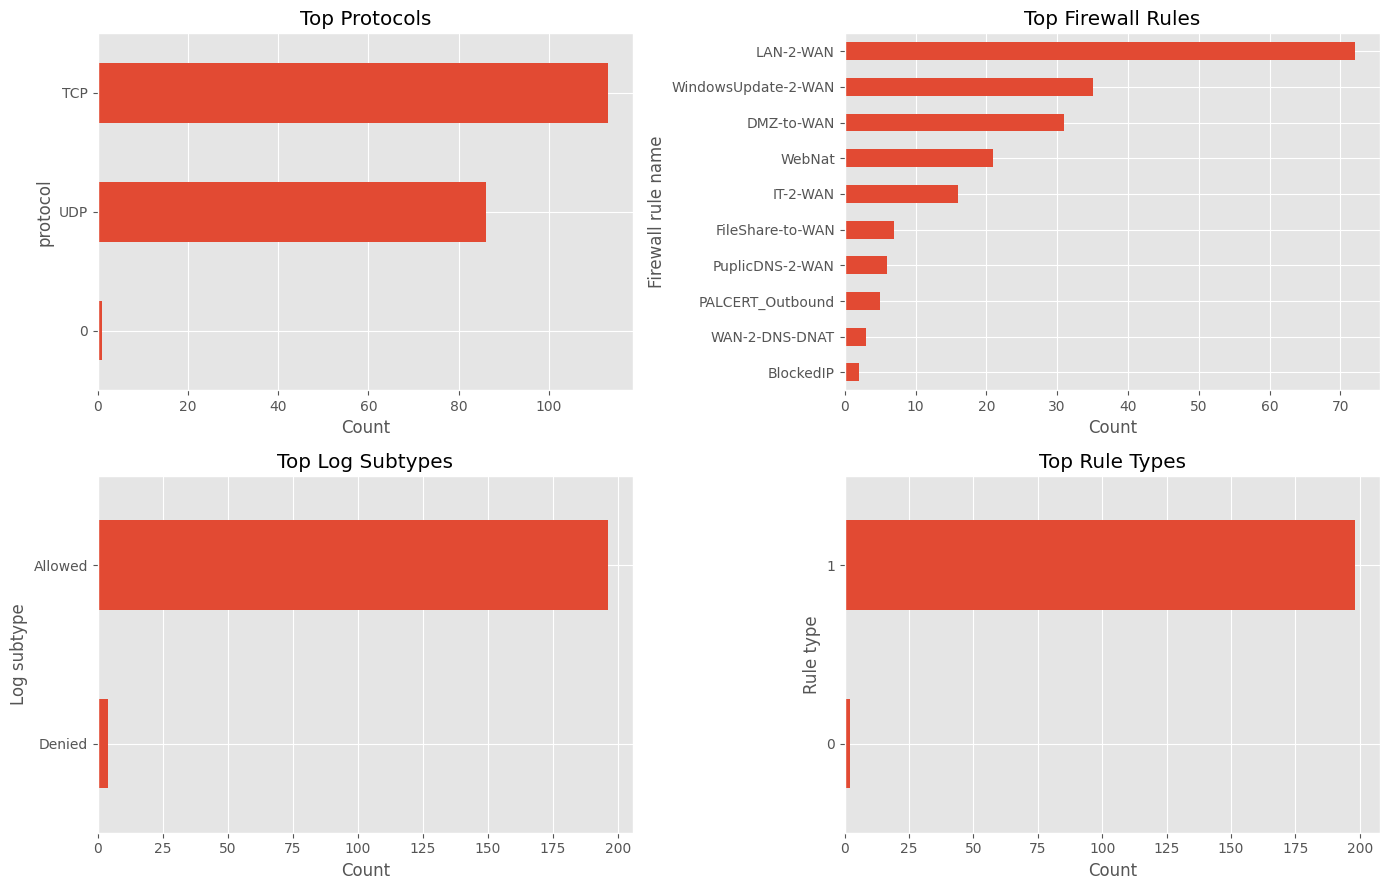

In [6]:
# Top categorical feature distributions
cat_features_to_plot = [
    ("protocol", "Top Protocols"),
    ("Firewall rule name", "Top Firewall Rules"),
    ("Log subtype", "Top Log Subtypes"),
    ("Rule type", "Top Rule Types"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, title) in zip(axes.flatten(), cat_features_to_plot):
    if col in df.columns:
        df[col].value_counts().head(10).plot(kind="barh", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Count")
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

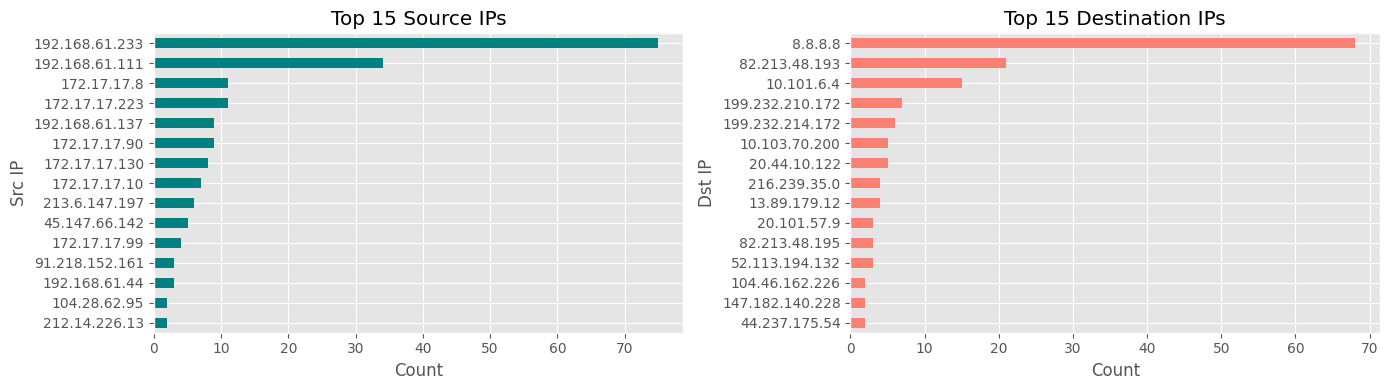

In [7]:
# Source and destination IP address frequency
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if "Src IP" in df.columns:
    df["Src IP"].value_counts().head(15).plot(kind="barh", ax=axes[0], color="teal")
    axes[0].set_title("Top 15 Source IPs")
    axes[0].set_xlabel("Count")
    axes[0].invert_yaxis()

if "Dst IP" in df.columns:
    df["Dst IP"].value_counts().head(15).plot(kind="barh", ax=axes[1], color="salmon")
    axes[1].set_title("Top 15 Destination IPs")
    axes[1].set_xlabel("Count")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

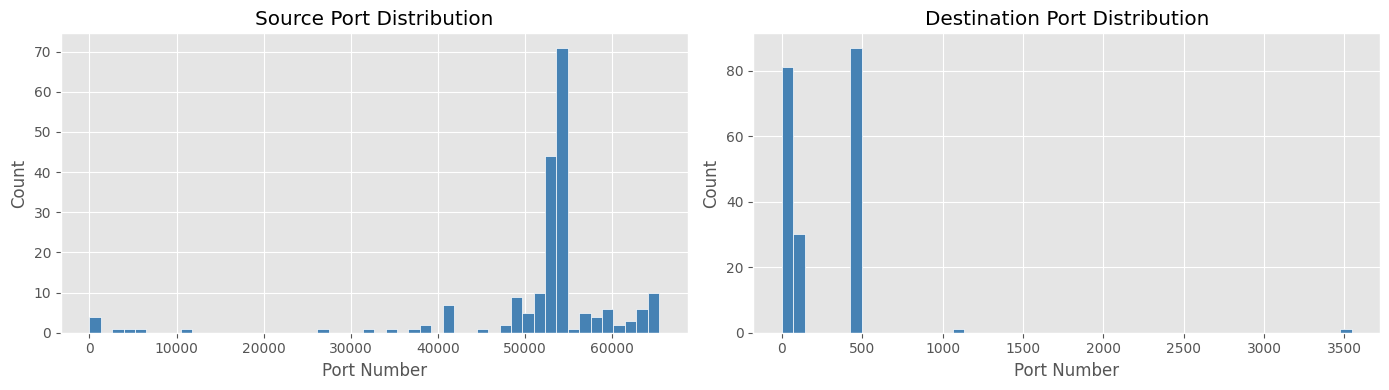

In [8]:
# Port number distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, title in [
    (axes[0], "Src port", "Source Port Distribution"),
    (axes[1], "Dst port", "Destination Port Distribution"),
]:
    if col in df.columns:
        ports = pd.to_numeric(df[col], errors="coerce").dropna()
        ax.hist(ports, bins=50, color="steelblue", edgecolor="white")
        ax.set_title(title)
        ax.set_xlabel("Port Number")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 5. Preprocessing & Feature Engineering

Operations performed:

- Removing unnamed or zero-variance columns
- Selecting a canonical column subset for analysis
- Temporal feature extraction: hour of day, day of week, epoch offset
- Port categorization into well-known, registered, and ephemeral ranges
- IP feature extraction: private/public flag, integer representation
- Entity frequency encoding for high-cardinality categoricals
- Text vectorization of the Message field using TF-IDF followed by dimensionality reduction via TruncatedSVD
- RobustScaler normalization to reduce the impact of extreme outliers

Since this is an unsupervised task with no train/test split, all transformations are fit on the full dataset. There is no risk of target leakage.

In [9]:
# Drop unnamed and zero-variance columns; restrict to known relevant columns
cols_to_drop = [c for c in df.columns if c.lower().startswith("unnamed") or df[c].nunique() == 0]
df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

canonical_cols = [
    "Time", "Log comp", "Log subtype", "Username", "Firewall rule",
    "Firewall rule name", "NAT rule", "NAT rule name", "In interface",
    "Out interface", "Src IP", "Dst IP", "Src port", "Dst port",
    "protocol", "Rule type", "Live PCAP", "Message", "Log occurrence",
    "hour", "dow", "date",
]
cols_present = [c for c in canonical_cols if c in df.columns]
df = df[cols_present].copy()

print("Retained columns:", df.columns.tolist())

Retained columns: ['Time', 'Log comp', 'Log subtype', 'Firewall rule', 'Firewall rule name', 'NAT rule', 'NAT rule name', 'Src IP', 'Dst IP', 'Src port', 'Dst port', 'protocol', 'Rule type', 'Live PCAP', 'Message', 'Log occurrence', 'hour', 'dow', 'date']


In [10]:
# Temporal features (time_epoch: seconds since first log entry)
df["time_epoch"] = (df["Time"] - df["Time"].min()).dt.total_seconds()

In [11]:
# Port categorization: well-known (<1024), registered (1024-49151), ephemeral (>49151)
def categorize_port(port):
    try:
        p = int(port)
    except (ValueError, TypeError):
        return "unknown"
    if p <= 0:
        return "unknown"
    if p < 1024:
        return "well-known"
    if p <= 49151:
        return "registered"
    return "ephemeral"

if "Src port" in df.columns:
    df["src_port_bin"] = df["Src port"].apply(categorize_port)
if "Dst port" in df.columns:
    df["dst_port_bin"] = df["Dst port"].apply(categorize_port)

In [12]:
# IP feature extraction: private flag and integer representation
def extract_ip_features(ip):
    try:
        ip_obj = ipaddress.ip_address(str(ip))
        return pd.Series([int(ip_obj.is_private), int(ip_obj)])
    except (ValueError, TypeError):
        return pd.Series([np.nan, np.nan])

for col in ["Src IP", "Dst IP"]:
    if col in df.columns:
        df[[f"{col}_is_private", f"{col}_int"]] = df[col].apply(extract_ip_features)

In [13]:
# Frequency encoding: how often each entity appears in the dataset
freq_cols = ["Username", "Src IP", "Dst IP", "Firewall rule name", "protocol"]
for col in freq_cols:
    if col in df.columns:
        freq_map = df[col].value_counts().to_dict()
        df[f"{col}_count"] = df[col].map(freq_map).fillna(0).astype(int)

In [14]:
# Text feature extraction: TF-IDF on Message column, reduced to 20 components via TruncatedSVD
if "Message" in df.columns:
    tfidf = TfidfVectorizer(max_features=2000, stop_words="english")
    text_matrix = tfidf.fit_transform(df["Message"].fillna(""))

    n_components = min(20, text_matrix.shape[1])
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    text_reduced = svd.fit_transform(text_matrix)

    for i in range(text_reduced.shape[1]):
        df[f"msg_svd_{i}"] = text_reduced[:, i]

    print(f"TF-IDF + SVD: added {n_components} message components")

TF-IDF + SVD: added 9 message components


In [15]:
# Select numeric features for clustering
base_numeric = [
    "hour", "dow", "time_epoch",
    "Src IP_is_private", "Dst IP_is_private",
    "Src IP_int", "Dst IP_int",
]
base_numeric = [c for c in base_numeric if c in df.columns]

count_features = [c for c in df.columns if c.endswith("_count")]
svd_features = [c for c in df.columns if c.startswith("msg_svd_")]

numeric_cols = sorted(set(base_numeric + count_features + svd_features))
print(f"Total numeric features for clustering: {len(numeric_cols)}")
print(numeric_cols)

Total numeric features for clustering: 20
['Dst IP_count', 'Dst IP_int', 'Dst IP_is_private', 'Firewall rule name_count', 'Src IP_count', 'Src IP_int', 'Src IP_is_private', 'dow', 'hour', 'msg_svd_0', 'msg_svd_1', 'msg_svd_2', 'msg_svd_3', 'msg_svd_4', 'msg_svd_5', 'msg_svd_6', 'msg_svd_7', 'msg_svd_8', 'protocol_count', 'time_epoch']


In [16]:
# Assemble feature matrix and scale with RobustScaler
X = df[numeric_cols].fillna(0).copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)

print("\nDescriptive statistics of numeric features:")
display(df[numeric_cols].describe())

Feature matrix shape: (200, 20)

Descriptive statistics of numeric features:


,Dst IP_count,Dst IP_int,Dst IP_is_private,Firewall rule name_count,Src IP_count,Src IP_int,Src IP_is_private,dow,hour,msg_svd_0,msg_svd_1,msg_svd_2,msg_svd_3,msg_svd_4,msg_svd_5,msg_svd_6,msg_svd_7,msg_svd_8,protocol_count,time_epoch
count,200.000000,2.000000e+02,200.000000,200.000000,200.000000,2.000000e+02,200.000000,200.0,200.0,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,200.000000,200.000000
mean,27.800000,9.459044e+08,0.110000,40.950000,37.080000,2.995433e+09,0.875000,5.0,12.0,0.007672,8.326673e-18,-9.020562e-19,9.540979e-20,-4.857226e-19,5.551115e-19,2.775558e-19,1.155558e-35,-1.649463e-19,100.830000,132.845000
std,29.538664,1.122251e+09,0.313675,25.023557,31.034648,5.798099e+08,0.331549,0.0,0.0,0.076523,6.430653e-02,1.181160e-17,1.349298e-18,4.894690e-18,7.850462e-18,3.925231e-18,1.634206e-34,2.711478e-18,15.140252,93.620806
min,1.000000,0.000000e+00,0.000000,0.000000,1.000000,0.000000e+00,0.000000,5.0,12.0,0.000000,-6.414556e-01,-1.665335e-16,0.000000e+00,-5.551115e-17,0.000000e+00,0.000000e+00,0.000000e+00,-3.799307e-17,1.000000,0.000000
25%,2.000000,1.347441e+08,0.000000,21.000000,8.000000,2.886800e+09,1.000000,5.0,12.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,86.000000,48.000000
50%,15.000000,3.384306e+08,0.000000,35.000000,34.000000,3.232251e+09,1.000000,5.0,12.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,113.000000,120.000000
75%,68.000000,1.389703e+09,0.000000,72.000000,75.000000,3.232251e+09,1.000000,5.0,12.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,113.000000,214.250000
max,68.000000,3.639551e+09,1.000000,72.000000,75.000000,3.573978e+09,1.000000,5.0,12.0,0.767160,6.414556e-01,0.000000e+00,1.908196e-17,0.000000e+00,1.110223e-16,5.551115e-17,2.311116e-33,5.003806e-18,113.000000,278.000000


## 6. Model Training

**Dimensionality Reduction:**  
PCA is applied before clustering to reduce noise and computational cost. Components are retained to explain 90% of the variance.

**Models Compared:**

| Model | Rationale |
|-------|----------|
| K-Means (k=2 to 10) | Baseline partition-based clustering, scalable and interpretable |
| Agglomerative Clustering (k=3 to 6) | Hierarchical approach, no assumption of spherical clusters |
| DBSCAN (eps=0.5 to 2.0) | Density-based, can detect noise and arbitrary-shape clusters |
| Gaussian Mixture Model (k=2 to 7) | Probabilistic soft assignments, flexible covariance structure |

**Training Strategy:**  
Full dataset is used (no train/test split in unsupervised setting). Internal metrics are computed on the full feature space.

In [17]:
# PCA: retain components explaining 90% of variance
pca = PCA(n_components=0.9, svd_solver="full", random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print("PCA output shape:", X_pca.shape)
print("Explained variance ratios (first 10):", pca.explained_variance_ratio_[:10].round(3))

PCA output shape: (200, 4)
Explained variance ratios (first 10): [0.577 0.191 0.074 0.065]


In [18]:
# Helper: fit a clustering model and record internal validation metrics
def evaluate_clustering(model, X_feat, label_name, results_list):
    t0 = datetime.now()
    labels = model.fit_predict(X_feat)
    elapsed = (datetime.now() - t0).total_seconds()

    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    if n_clusters > 1:
        sil = silhouette_score(X_feat, labels)
        db = davies_bouldin_score(X_feat, labels)
        ch = calinski_harabasz_score(X_feat, labels)
    else:
        sil = db = ch = np.nan

    results_list.append({
        "model": label_name,
        "n_clusters": n_clusters,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "time_s": elapsed,
        "labels": labels,
    })
    return labels

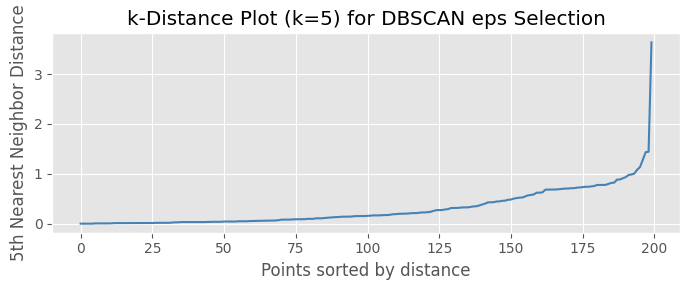

Model training completed


In [19]:
results = []

# K-Means: sweep k from 2 to 10
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    evaluate_clustering(model, X_pca, f"KMeans_k{k}", results)

# Agglomerative Clustering: Ward linkage, k from 3 to 6
for k in [3, 4, 5, 6]:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    evaluate_clustering(model, X_pca, f"Agglomerative_k{k}", results)

# DBSCAN: k-distance plot to aid eps selection
nbrs = NearestNeighbors(n_neighbors=5).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 3))
plt.plot(k_distances, color="steelblue")
plt.title("k-Distance Plot (k=5) for DBSCAN eps Selection")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.tight_layout()
plt.show()

# DBSCAN: sweep eps values
for eps in [0.5, 1.0, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=5)
    evaluate_clustering(model, X_pca, f"DBSCAN_eps{eps}", results)

# Gaussian Mixture Model: sweep k from 2 to 7
for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, random_state=SEED)
    gmm.fit(X_pca)
    labels = gmm.predict(X_pca)
    n_clusters = len(set(labels))

    sil = silhouette_score(X_pca, labels) if n_clusters > 1 else np.nan
    db = davies_bouldin_score(X_pca, labels) if n_clusters > 1 else np.nan
    ch = calinski_harabasz_score(X_pca, labels) if n_clusters > 1 else np.nan

    results.append({
        "model": f"GMM_k{k}",
        "n_clusters": n_clusters,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "time_s": np.nan,
        "labels": labels,
    })

print("Model training completed")

## 7. Model Evaluation

Models are ranked by Silhouette Score (higher is better). Davies-Bouldin (lower is better) and Calinski-Harabasz (higher is better) are used as complementary metrics.

- Silhouette Score: measures mean intra-cluster cohesion vs. nearest-cluster separation. Values near 1 indicate well-separated clusters.
- Davies-Bouldin Index: ratio of within-cluster scatter to between-cluster separation. Lower values indicate more compact, well-separated clusters.
- Calinski-Harabasz Index: ratio of between-cluster dispersion to within-cluster dispersion. Higher values favor dense, well-separated clusters.

In [20]:
# Build results dataframe, sorted by Silhouette Score
results_df = (
    pd.DataFrame(results)
    .sort_values(by="silhouette", ascending=False)
    .reset_index(drop=True)
)

display(
    results_df[["model", "n_clusters", "silhouette", "davies_bouldin", "calinski_harabasz", "time_s"]]
    .head(15)
    .round(4)
)

best = results_df.iloc[0]
best_labels = best["labels"]
df["cluster"] = best_labels

print(f"\nBest model: {best['model']}")
print(f"Clusters: {best['n_clusters']}, Silhouette: {best['silhouette']:.4f}")

,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,time_s
0,KMeans_k2,2,0.6949,0.4579,234.5782,0.0243
1,GMM_k2,2,0.6949,0.4579,234.5782,NaN
2,DBSCAN_eps2.0,2,0.6763,0.3703,126.8581,0.0009
3,DBSCAN_eps1.5,3,0.6263,0.3534,90.0780,0.0009
4,KMeans_k10,10,0.5597,0.5921,307.2065,0.0055
5,KMeans_k9,9,0.5533,0.7052,288.1991,0.0048
6,KMeans_k8,8,0.5405,0.7022,276.8820,0.0053
7,KMeans_k6,6,0.5300,0.6847,257.2810,0.0054
8,KMeans_k7,7,0.5262,0.7191,271.4451,0.0048
9,Agglomerative_k6,6,0.5195,0.7682,246.6310,0.0005



Best model: KMeans_k2
Clusters: 2, Silhouette: 0.6949


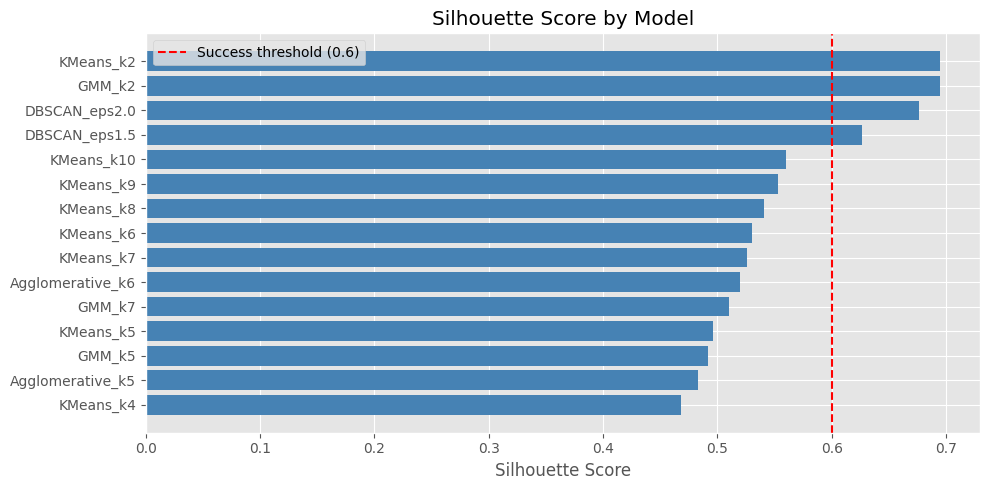

In [21]:
# Silhouette score comparison across all valid models
plot_df = results_df.dropna(subset=["silhouette"]).head(15)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["model"][::-1], plot_df["silhouette"][::-1], color="steelblue")
plt.axvline(x=0.6, color="red", linestyle="--", label="Success threshold (0.6)")
plt.title("Silhouette Score by Model")
plt.xlabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

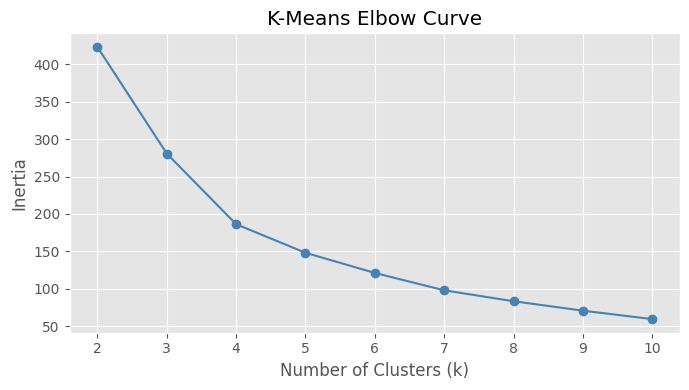

In [22]:
# K-Means elbow analysis: inertia vs. number of clusters
kmeans_results = results_df[results_df["model"].str.startswith("KMeans")].copy()
kmeans_results["k"] = kmeans_results["model"].str.extract(r"k(\d+)").astype(int)
kmeans_inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_pca)
    kmeans_inertia.append({"k": k, "inertia": km.inertia_})

inertia_df = pd.DataFrame(kmeans_inertia)

plt.figure(figsize=(7, 4))
plt.plot(inertia_df["k"], inertia_df["inertia"], marker="o", color="steelblue")
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

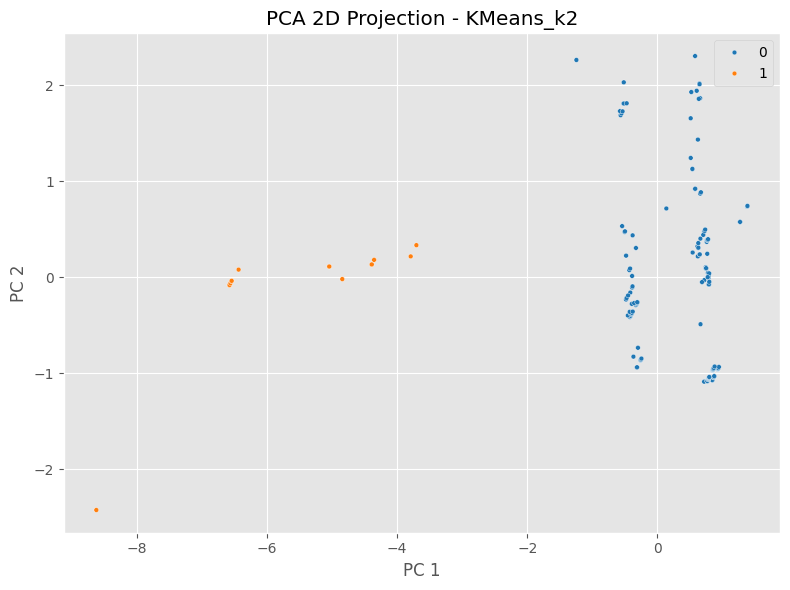

In [23]:
# PCA 2D projection colored by best cluster assignment
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_2d[:, 0], y=X_2d[:, 1],
    hue=best_labels,
    palette="tab10",
    s=12,
    legend="full",
)
plt.title(f"PCA 2D Projection - {best['model']}")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

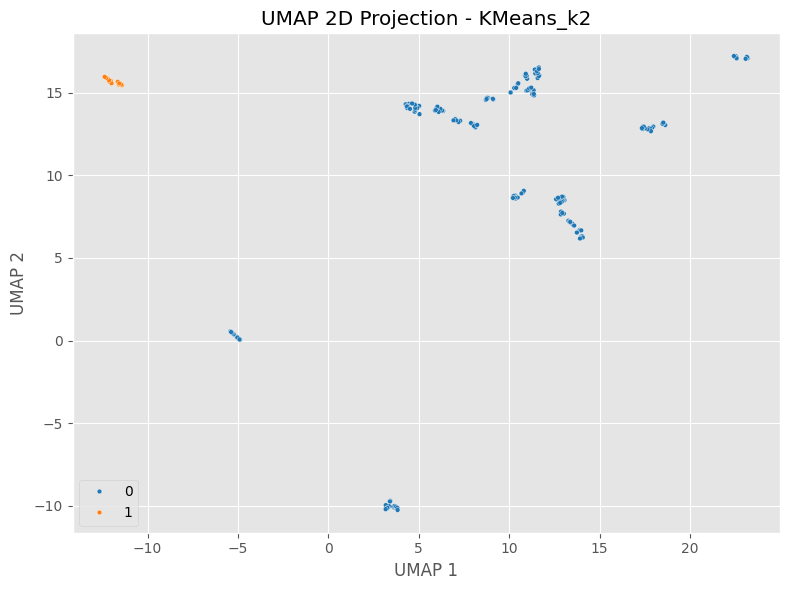

In [27]:
# UMAP 2D projection (only if umap-learn is installed)
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, random_state=SEED)
    X_umap = reducer.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=X_umap[:, 0], y=X_umap[:, 1],
        hue=best_labels,
        palette="tab10",
        s=12,
        legend="full",
    )
    plt.title(f"UMAP 2D Projection - {best['model']}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.tight_layout()
    plt.show()
else:
    print("UMAP not available. Install umap-learn to enable this visualization.")

In [28]:
# Cluster profile: mean values of key numeric features per cluster
profile_cols = [c for c in ["hour", "dow", "Src IP_is_private", "Dst IP_is_private"] + count_features if c in df.columns]
cluster_profile = df.groupby("cluster")[profile_cols].mean().round(3)

print("Cluster mean profiles:")
display(cluster_profile)

Cluster mean profiles:


,hour,dow,Src IP_is_private,Dst IP_is_private,Src IP_count,Dst IP_count,Firewall rule name_count,protocol_count
cluster,,,,,,,,
0,12.0,5.0,0.941,0.114,39.843,28.557,42.778,100.595
1,12.0,5.0,0.067,0.067,3.000,18.467,18.400,103.733


In [29]:
# Cluster composition: top protocol and firewall rule per cluster
for col in ["protocol", "Firewall rule name", "Log subtype", "Rule type"]:
    if col in df.columns:
        print(f"\nTop values of '{col}' per cluster:")
        display(
            df.groupby("cluster")[col]
            .apply(lambda s: s.value_counts().head(3).to_dict())
        )


Top values of 'protocol' per cluster:


cluster     
0        TCP    100.0
         UDP     85.0
         0        NaN
1        TCP     13.0
         UDP      1.0
         0        1.0
Name: protocol, dtype: float64


Top values of 'Firewall rule name' per cluster:


cluster                     
0        LAN-2-WAN              72.0
         WindowsUpdate-2-WAN    35.0
         DMZ-to-WAN             31.0
         WebNat                  NaN
         WAN-2-DNS-DNAT          NaN
1        LAN-2-WAN               NaN
         WindowsUpdate-2-WAN     NaN
         DMZ-to-WAN              NaN
         WebNat                 13.0
         WAN-2-DNS-DNAT          1.0
Name: Firewall rule name, dtype: float64


Top values of 'Log subtype' per cluster:


cluster         
0        Allowed    182
         Denied       3
1        Allowed     14
         Denied       1
Name: Log subtype, dtype: int64


Top values of 'Rule type' per cluster:


cluster   
0        1    184
         0      1
1        1     14
         0      1
Name: Rule type, dtype: int64

## 8. Conclusions & Next Steps

### Key Findings

The dataset contains 200 firewall log events captured within a single five-minute window on a Saturday afternoon (2024-07-06, 12:25 to 12:30). All records share the same hour and day-of-week values, so those two features carry zero discriminative signal. The Username field is entirely missing (200/200 NaN) and the Message field is 99% missing (198/200 NaN), leaving only two distinct message strings, which produced nine TF-IDF/SVD components of which components 2 through 8 are numerical noise at the floating-point precision level (~1e-16 to 1e-34). The effective feature space is therefore driven by IP addressing, frequency encoding, and firewall rule associations.

Traffic composition is heavily skewed toward outbound connections: 87.5% of source IPs are RFC1918 private addresses, TCP accounts for 113 of 200 events, destination port 443 dominates, and the top destination is 8.8.8.8 (68 events). Ten distinct firewall rule names are present, with LAN-2-WAN (72), WindowsUpdate-2-WAN (35), and DMZ-to-WAN (31) covering the majority of outbound traffic, while WebNat (13) and WAN-2-DNS-DNAT (1) represent inbound NAT translations.

### Model Performance vs Success Criteria

The success criterion was a Silhouette Score above 0.6. K-Means with k=2 achieved a Silhouette of 0.6949 and a Davies-Bouldin index of 0.4579, meeting the threshold. GMM with k=2 produced an identical partition (Silhouette=0.6949, DB=0.4579), confirming the stability of the two-cluster structure. DBSCAN with eps=2.0 reached a Silhouette of 0.6763 and the best Davies-Bouldin of 0.3703, indicating tighter cluster compactness but at the cost of a lower Calinski-Harabasz score (126.86 vs 234.58 for KMeans k=2).

Increasing k beyond 2 consistently degrades the Silhouette Score, dropping to 0.56 at k=10 and below 0.50 at k=4, suggesting that finer partitions do not correspond to genuinely separable structures in this dataset. The elbow curve confirms no strong inflection point beyond k=2.

PCA reduced the 20-feature matrix to 4 components explaining 90% of variance (PC1=57.7%, PC2=19.1%, PC3=7.4%, PC4=6.5%). The dominance of PC1 indicates that a single latent axis, most likely the private/public IP distinction combined with frequency counts, drives most of the separation.

### Interpretation

The two clusters correspond to structurally distinct traffic directions:

Cluster 0 (185 events, 92.5% of the dataset) represents outbound LAN and DMZ traffic. Source IPs are private in 94.1% of cases, source IP counts are high (mean 39.8, indicating a small set of active internal hosts), and the dominant rules are LAN-2-WAN, WindowsUpdate-2-WAN, and DMZ-to-WAN. This segment is consistent with routine internal host activity browsing the internet and performing software updates.

Cluster 1 (15 events, 7.5%) represents inbound externally-initiated connections. Source IPs are almost entirely public (only 6.7% private), source IP counts are very low (mean 3.0, indicating rare or one-time external sources), and the active rules are WebNat and WAN-2-DNS-DNAT, which translate inbound requests to internal servers. This segment warrants closer security scrutiny, as it covers traffic arriving from outside the perimeter and being forwarded to internal resources via NAT.

Both clusters show near-identical denied event ratios (cluster 0: 3 denied, cluster 1: 1 denied), so denial rate alone does not differentiate them. The separation is driven primarily by source IP locality and firewall rule identity.

### Limitations

The dataset covers a single five-minute capture window with 200 records, which is insufficient to represent daily, weekly, or seasonal traffic variation. Any clustering solution derived from this sample will not generalize to production traffic without retraining on a broader time range.

Two features with zero variance (hour and dow) were retained in the feature matrix. While RobustScaler and PCA neutralize their contribution in practice, explicitly removing them before scaling would be cleaner and reduce noise in PCA variance decomposition.

The TF-IDF/SVD message components (msg_svd_2 through msg_svd_8) are zero-variance noise due to the near-complete absence of the Message field. Their presence inflates the feature count without adding signal and should be filtered out.

The Calinski-Harabasz index favors higher k values (307.21 at k=10), conflicting with the Silhouette and Davies-Bouldin signals. This divergence is a known artifact in datasets with elongated or unequal-density clusters, and it limits the interpretability of CH as a standalone selection criterion here.

### Next Steps

Collect a longer log sample spanning at least several days and multiple hours to introduce meaningful temporal variance. The current dataset is effectively a snapshot with no temporal discriminative power.

Remove zero-variance features (hour, dow in this capture) and near-zero-variance SVD components before scaling to reduce dimensionality noise. A variance threshold filter applied before PCA would automate this.

Engineer additional features from available fields: destination port categorization (e.g., DNS on 53, HTTPS on 443, custom on >1024), NAT rule type encoding, and source-to-destination IP pair frequency as a proxy for persistent connections.

Isolate cluster 1 (inbound external connections via WebNat) for deeper analysis. With more data, applying DBSCAN or Isolation Forest specifically to this subset could surface anomalous inbound sources that deviate from the baseline NAT pattern.

Evaluate clustering stability with bootstrap resampling to confirm that the k=2 structure is not an artifact of the small sample size.